# Tutorials_ST_SM

In [1]:
import scanpy as sc
import torch
import os
import pandas as pd


In [2]:
import community as louvain
import AgaeSMO as AgaeSMO_v1

In [3]:
random_seed = 2022
AgaeSMO_v1.fix_seed(random_seed)
# In[4]:


device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')

# the location of R, which is required for the 'mclust' algorithm. Please replace the path below with local R installation path
os.environ['R_HOME'] = '/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/R' 


data of demo deposited in https://drive.google.com/drive/folders/1eK5zSKmSV2eaQ9jhIEcKPXwuiWaGfldH?usp=sharing

In [4]:

adata_omics1 = sc.read_h5ad("data/SMA/st.h5ad")
adata_omics2 = sc.read_h5ad("data/SMA/ms.h5ad")

adata_omics1.var_names_make_unique()
adata_omics2.var_names_make_unique()

print(adata_omics1)
print(adata_omics2)

AnnData object with n_obs × n_vars = 2675 × 32285
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 2438 × 1538
    obs: 'array_row', 'array_col'
    uns: 'spatial'
    obsm: 'spatial'


/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


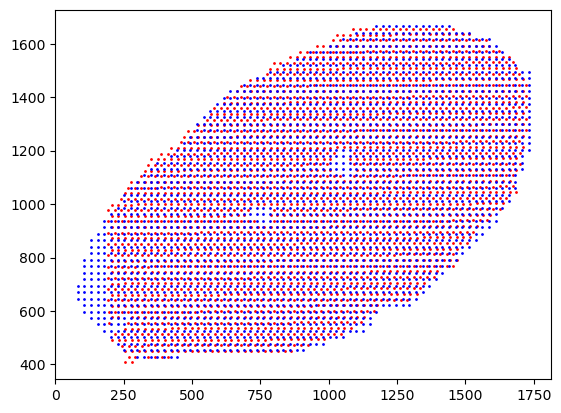

In [5]:

st_keys=list(adata_omics1.uns["spatial"].keys())[0]
adata_omics1.obsm["HE_domain_coor"]=adata_omics1.obsm["spatial"]*adata_omics1.uns["spatial"][st_keys]["scalefactors"]["tissue_hires_scalef"]
adata_omics2.obsm["HE_domain_coor"]=adata_omics2.obsm["spatial"]
import matplotlib.pyplot as plt
plt.scatter(adata_omics1.obsm["HE_domain_coor"][:,0],adata_omics1.obsm["HE_domain_coor"][:,1],s=1,c="red")
plt.scatter(adata_omics2.obsm["HE_domain_coor"][:,0],adata_omics2.obsm["HE_domain_coor"][:,1],s=1,c="blue")



In [6]:
sc.pp.filter_genes(adata_omics1, min_cells=10)
sc.pp.highly_variable_genes(adata_omics1, flavor="seurat_v3", n_top_genes=2000)
sc.pp.normalize_total(adata_omics1, target_sum=1e4)
sc.pp.log1p(adata_omics1)
# sc.pp.scale(adata_omics1)

# sc.pp.filter_genes(adata_omics2, min_cells=10)
sc.pp.highly_variable_genes(adata_omics2, flavor="seurat_v3", n_top_genes=1000)
# sc.pp.normalize_total(adata_omics2, target_sum=1e4)
sc.pp.log1p(adata_omics2)
# sc.pp.scale(adata_omics2)

/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


In [7]:
adata_omics1_high =  adata_omics1[:, adata_omics1.var['highly_variable']]
adata_omics1.obsm['feat'] = AgaeSMO_v1.pca(adata_omics1_high, n_comps=30)
# adata_omics1.obsm['tensor']=adata_omics1[:, adata_omics1.var['highly_variable']].X.toarray()
adata_omics1.obsm['tensor']=AgaeSMO_v1.pca(adata_omics1_high, n_comps=100)
# Protein
# adata_omics2 = AgaeSMO_v1.clr_normalize_each_cell(adata_omics2) 
# sc.pp.scale(adata_omics2)
# adata_omics2_high =  adata_omics2[:, adata_omics2.var['highly_variable']]
adata_omics2.obsm['feat'] = AgaeSMO_v1.pca(adata_omics2, n_comps=30)
# adata_omics2.obsm['tensor']=adata_omics2[:, adata_omics2.var['highly_variable']].X.toarray()
# adata_omics2.obsm['tensor']=adata_omics2.X.toarray()
adata_omics2.obsm['tensor']=AgaeSMO_v1.pca(adata_omics2, n_comps=100)

------Calculating spatial graph...
The graph contains 15568 edges, 2675 cells.
5.8198 neighbors per cell on average.
------Calculating spatial graph...


/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/utils.py:529: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['adj_spatial_']['Cell1']))
/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/utils.py:529: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['adj_spatial_']['Cell1']))


The graph contains 9510 edges, 2438 cells.
3.9007 neighbors per cell on average.


/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/utils.py:529: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['adj_spatial_']['Cell1']))
/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/utils.py:529: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plot_df = pd.value_counts(pd.value_counts(adata.uns['adj_spatial_']['Cell1']))


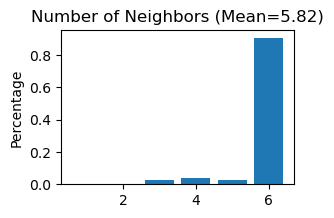

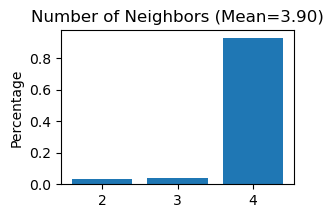

In [8]:
data = AgaeSMO_v1.construct_neighbor_graph(adata_omics1, adata_omics2,6,4,k=6)

In [9]:
model = AgaeSMO_v1.Train_AgaeSMO(data, device=device,epochs=600,learning_rate=0.001,weight_decay=0.005,trans_ngb=12,loss_weight=[1,1,1,1])

# train model
output = model.train()


# In[13]:


adata = adata_omics1.copy()
adata.obsm['emb_latent_omics1'] = output['emb_latent_omics1'].copy()
adata.obsm['emb_latent_omics2'] = output['emb_latent_omics2'].copy()
adata.obsm['AgaeSMO'] = output['AgaeSMO'].copy()
adata.obsm['alpha'] = output['alpha']

spot number is not equal,adding graph transfer
torch.Size([2675, 100]) torch.Size([2438, 100])
dim_input1 100 dim_input2 100 
 dim_output1 30 dim_output2 30


  0%|          | 0/600 [00:00<?, ?it/s]/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/torch/nn/functional.py:1956: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")
/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/AgaeSMO/layer.py:250: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  self.alpha = F.softmax(torch.squeeze(self.vu) + 1e-6)
  0%|          | 1/600 [00:04<46:57,  4.70s/it]

epoch:0 2.4103517532348633


  2%|▏         | 12/600 [00:05<01:42,  5.73it/s]

epoch:10 1.178350567817688


...

epoch:580 0.38975200057029724


 99%|█████████▊| 592/600 [01:10<00:00,  8.25it/s]

epoch:590 0.39128002524375916


100%|██████████| 600/600 [01:11<00:00,  8.40it/s]


Model training finished!



R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software/anaconda3/envs/pyg1/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to a

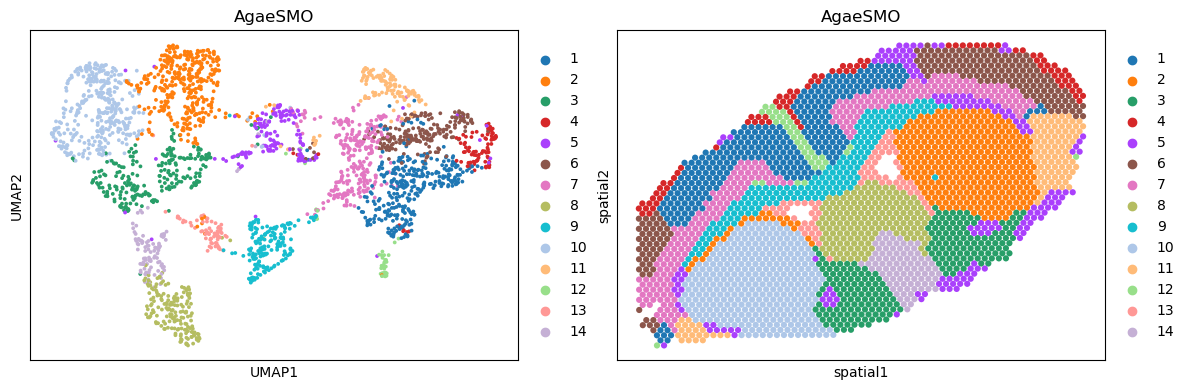

In [10]:

n_cluster=14
tool = 'mclust' # mclust, leiden, and louvain  
AgaeSMO_v1.clustering(adata,refine_=True, key='AgaeSMO', add_key='AgaeSMO', n_clusters=n_cluster, method=tool, use_pca=True)# visualization
import matplotlib.pyplot as plt
fig, ax_list = plt.subplots(1, 2, figsize=(12, 4))
sc.pp.neighbors(adata, use_rep='AgaeSMO', n_neighbors=10)
sc.tl.umap(adata)

sc.pl.umap(adata, color='AgaeSMO', ax=ax_list[0], title='AgaeSMO', s=30, show=False)
sc.pl.embedding(adata, basis='spatial', color='AgaeSMO', ax=ax_list[1], title='AgaeSMO', s=80, show=False)

plt.tight_layout(w_pad=0.3)
plt.show()

